<a href="https://colab.research.google.com/github/benishshrestha66/Projects/blob/main/Prescriptive%20Analytics-Cholera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Choleraa.xlsx to Choleraa.xlsx


In [ ]:

df = pd.read_excel("Choleraa.xlsx")
df.head()

,EpidNo,state,epiweek,season,setting,healthfac_type,geo,sex,age,age_cat,...,cult_cat,cult_bin,outcome,heathfac_presn,sample_tak,tested,sec,flood,flood_cat,lga_new
0,NIE-KNS-GWL-18-046,Kano,W01,dry season,urban,NaN,north-west,female,80.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Gwale
1,NIE-KNS-UGG-18-061,Kano,W01,dry season,rural,NaN,north-west,female,25.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
2,NIE-KNS-UGG-18-065,Kano,W01,dry season,rural,NaN,north-west,male,15.0,15 years & above,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
3,NIE-KNS-UGG-18-063,Kano,W01,dry season,rural,NaN,north-west,male,12.0,11-14 yrs,...,NaN,NaN,alive,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Ungogo
4,NIE-KNS-FGE-18-039,Kano,W01,dry season,urban,NaN,north-west,male,15.0,15 years & above,...,NaN,NaN,dead,NaN,no,no,No insurgency,reported flooding i 2018,mild flooding in 2018,Fagge


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.dropna()

df.head()

,epidno,state,epiweek,season,setting,healthfac_type,geo,sex,age,age_cat,...,cult_cat,cult_bin,outcome,heathfac_presn,sample_tak,tested,sec,flood,flood_cat,lga_new
15064,NIE-PLS-JJN-18-260,Plateau,W25,rainy season,urban,Primary,north-central,male,73.0,15 years & above,...,positive,positive,alive,yes,yes,yes,No insurgency,reported flooding i 2018,mild flooding in 2018,Jos North
15609,NIE-PLS-BUU-18-001,Plateau,W25,rainy season,urban,Tertiary,north-central,female,37.0,15 years & above,...,positive,positive,alive,yes,yes,yes,No insurgency,reported flooding i 2018,mild flooding in 2018,Jos North


In [ ]:
print(df.columns)

Index(['epidno', 'state', 'epiweek', 'season', 'setting', 'healthfac_type',
       'geo', 'sex', 'age', 'age_cat', 'age_cat2', 'rdt_cat', 'rdt_bin',
       'cult_cat', 'cult_bin', 'outcome', 'heathfac_presn', 'sample_tak',
       'tested', 'sec', 'flood', 'flood_cat', 'lga_new'],
      dtype='object')


In [ ]:
df = df.sort_values(["state", "epiweek"])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
epidno,0
state,0
epiweek,0
season,0
setting,0
healthfac_type,0
geo,0
sex,0
age,0
age_cat,0


In [ ]:
df = pd.read_excel("Choleraa.xlsx", na_values=["NA", "N/A", "null", "", " ", -1, 999])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cult_bin,43863
cult_cat,43859
rdt_bin,42903
rdt_cat,42900
healthfac_type,28298
sample_tak,21260
heathfac_presn,17676
EpidNo,10446
age,1361
age_cat,1361


In [ ]:
df = df.drop(columns=["cult_bin", "cult_cat", "rdt_bin", "rdt_cat"], errors="ignore")

In [ ]:
df["age"] = df["age"].fillna(df.groupby("state")["age"].transform("median"))

In [ ]:
cat_cols = ["setting", "healthfac_type", "sample_tak", "heathfac_presn"]

for col in cat_cols:
  if col in df.columns:
    df[col] = df[col].fillna("Unknown")

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
EpidNo,10446
age_cat2,1361
age_cat,1361
sex,1
state,0
epiweek,0
season,0
geo,0
healthfac_type,0
setting,0


In [ ]:
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
EpidNo,10446
age_cat2,1361
age_cat,1361
sex,1
state,0
epiweek,0
season,0
geo,0
healthfac_type,0
setting,0


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
EpidNo,10446
age_cat2,1361
age_cat,1361
epiweek,0
state,0
season,0
setting,0
geo,0
healthfac_type,0
age,0


In [ ]:
df = df.drop(columns=["EpidNo"])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
age_cat2,1361
age_cat,1361
epiweek,0
state,0
season,0
setting,0
geo,0
healthfac_type,0
age,0
sex,0


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib -q
print('✅ Libraries installed!')

✅ Libraries installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score
import xgboost as xgb



In [ ]:
FILENAME = 'Choleraa.xlsx'   # <-- CHANGE THIS to your actual filename

# Use read_excel for .xlsx files, or read_csv for .csv files
df = pd.read_excel(FILENAME)
print(f'✅ Loaded! Shape: {df.shape}')

# === CONFIRMED FEATURES (15 features, 0 missing values) ===
FEATURES = [
    'state', 'epiweek', 'season', 'setting', 'healthfac_type',
    'geo', 'sex', 'age',
    'heathfac_presn', 'sample_tak', 'tested', 'sec',
    'flood', 'flood_cat', 'lga_new'
]
TARGET = 'outcome'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Encode target (e.g. Alive=0, Death=1)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y.astype(str))
print(f'Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Encode categorical features
label_encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X = X.apply(pd.to_numeric, errors='coerce')

# === CONFIRM THE IMBALANCE ===
death_rate = (y_encoded == 1).mean() * 100
print(f'\nDeath rate: {death_rate:.2f}%')
print(f'Class counts: {pd.Series(y_encoded).value_counts().to_dict()}')

# Train/test split — stratified to preserve the rare death class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# === IMBALANCE FIX: class weighting via scale_pos_weight ===
n_alive = (y_train == 0).sum()
n_death = (y_train == 1).sum()
scale_pos_weight = n_alive / n_death
print(f'\nscale_pos_weight = {scale_pos_weight:.1f}')
print(f'(Tells XGBoost: a missed death is {scale_pos_weight:.0f}x worse than a false alarm)')

# Train XGBoost model WITH class weighting (handles the 1.9% imbalance)
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,   # <-- handles the imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
print(f'\n✅ Model trained. Test accuracy: {xgb_model.score(X_test, y_test):.3f}')

# === Tune decision threshold for best F1 (better than default 0.5) ===
proba_test = xgb_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.05, 0.55, 0.05)
best_f1, DECISION_THRESHOLD = 0, 0.5

for t in thresholds:
    preds_t = (proba_test >= t).astype(int)
    f1 = f1_score(y_test, preds_t, zero_division=0)
    if f1 > best_f1:
        best_f1, DECISION_THRESHOLD = f1, t

preds_test = (proba_test >= DECISION_THRESHOLD).astype(int)
print(f'\nTuned decision threshold: {DECISION_THRESHOLD:.2f}')
print(f'Recall at this threshold:    {recall_score(y_test, preds_test):.3f}  ← catches this fraction of deaths')
print(f'Precision at this threshold: {precision_score(y_test, preds_test):.3f}')
print(f'F1 Score at this threshold:  {f1_score(y_test, preds_test):.3f}')

✅ Loaded! Shape: (43996, 23)
Target encoding: {'alive': np.int64(0), 'dead': np.int64(1)}

Death rate: 1.90%
Class counts: {0: 43160, 1: 836}

scale_pos_weight = 51.6
(Tells XGBoost: a missed death is 52x worse than a false alarm)

✅ Model trained. Test accuracy: 0.709

Tuned decision threshold: 0.50
Recall at this threshold:    0.677  ← catches this fraction of deaths
Precision at this threshold: 0.043
F1 Score at this threshold:  0.081


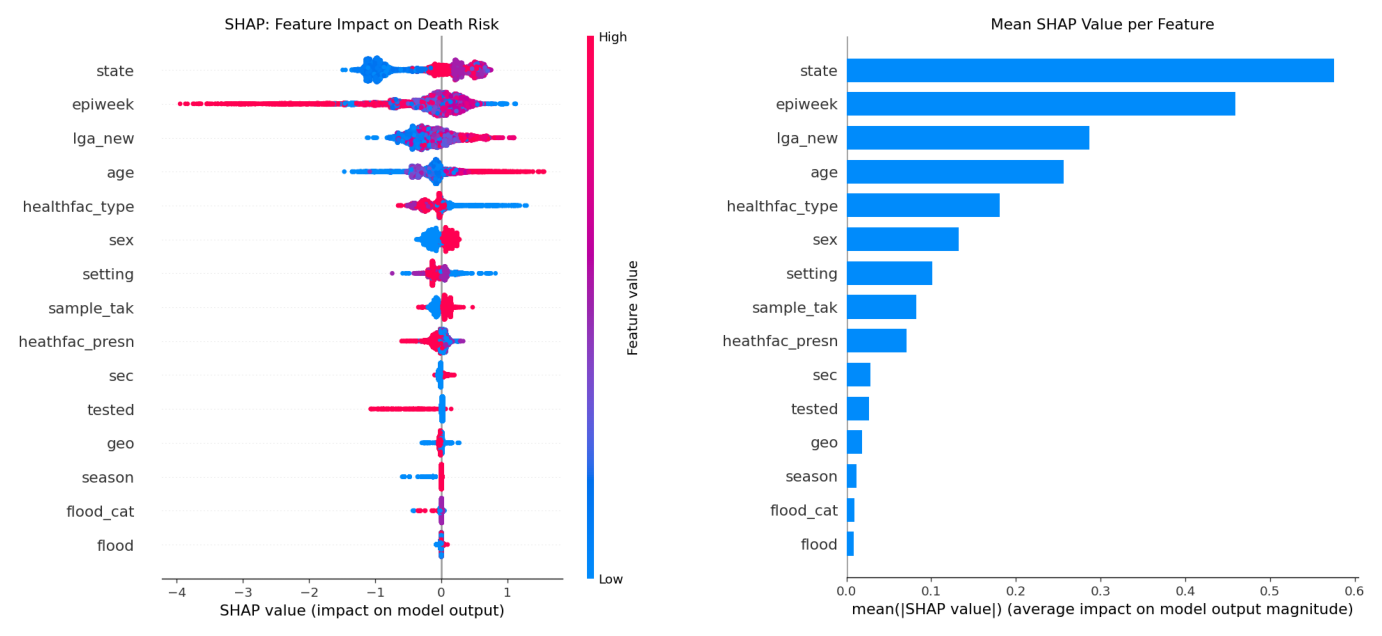


 Notes:
  Top features = most influence on outcome
  Red dots with positive X = high value raises death risk
  Blue dots with negative X = low value reduces death risk


In [ ]:
import matplotlib.image as mpimg
import io

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- Render beeswarm plot to memory ---
fig1 = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP: Feature Impact on Death Risk', fontsize=13)
plt.tight_layout()
buf1 = io.BytesIO()
plt.savefig(buf1, format='png', dpi=120, bbox_inches='tight')
plt.close(fig1)
buf1.seek(0)

# --- Render bar chart to memory ---
fig2 = plt.figure(figsize=(8, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('Mean SHAP Value per Feature', fontsize=13)
plt.tight_layout()
buf2 = io.BytesIO()
plt.savefig(buf2, format='png', dpi=120, bbox_inches='tight')
plt.close(fig2)
buf2.seek(0)

# --- Combine side by side with real spacing ---
img1 = mpimg.imread(buf1)
img2 = mpimg.imread(buf2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(img1)
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].axis('off')
plt.subplots_adjust(wspace=0.05)  # <-- controls the gap between them
plt.show()

print('\n Notes:')
print('  Top features = most influence on outcome')
print('  Red dots with positive X = high value raises death risk')
print('  Blue dots with negative X = low value reduces death risk')

Decision Tree Accuracy: 0.575

=== IF-THEN DECISION RULES ===
|--- state <= 3.50
|   |--- healthfac_type <= 2.50
|   |   |--- age <= 24.50
|   |   |   |--- epiweek <= 32.50
|   |   |   |   |--- class: 1
|   |   |   |--- epiweek >  32.50
|   |   |   |   |--- class: 0
|   |   |--- age >  24.50
|   |   |   |--- heathfac_presn <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- heathfac_presn >  0.50
|   |   |   |   |--- class: 1
|   |--- healthfac_type >  2.50
|   |   |--- lga_new <= 197.50
|   |   |   |--- age <= 59.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  59.50
|   |   |   |   |--- class: 0
|   |   |--- lga_new >  197.50
|   |   |   |--- epiweek <= 19.50
|   |   |   |   |--- class: 1
|   |   |   |--- epiweek >  19.50
|   |   |   |   |--- class: 0
|--- state >  3.50
|   |--- epiweek <= 36.50
|   |   |--- state <= 18.50
|   |   |   |--- age <= 42.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  42.50
|   |   |   |   |--- class: 1
|   |   |--- state >  18.50
|   

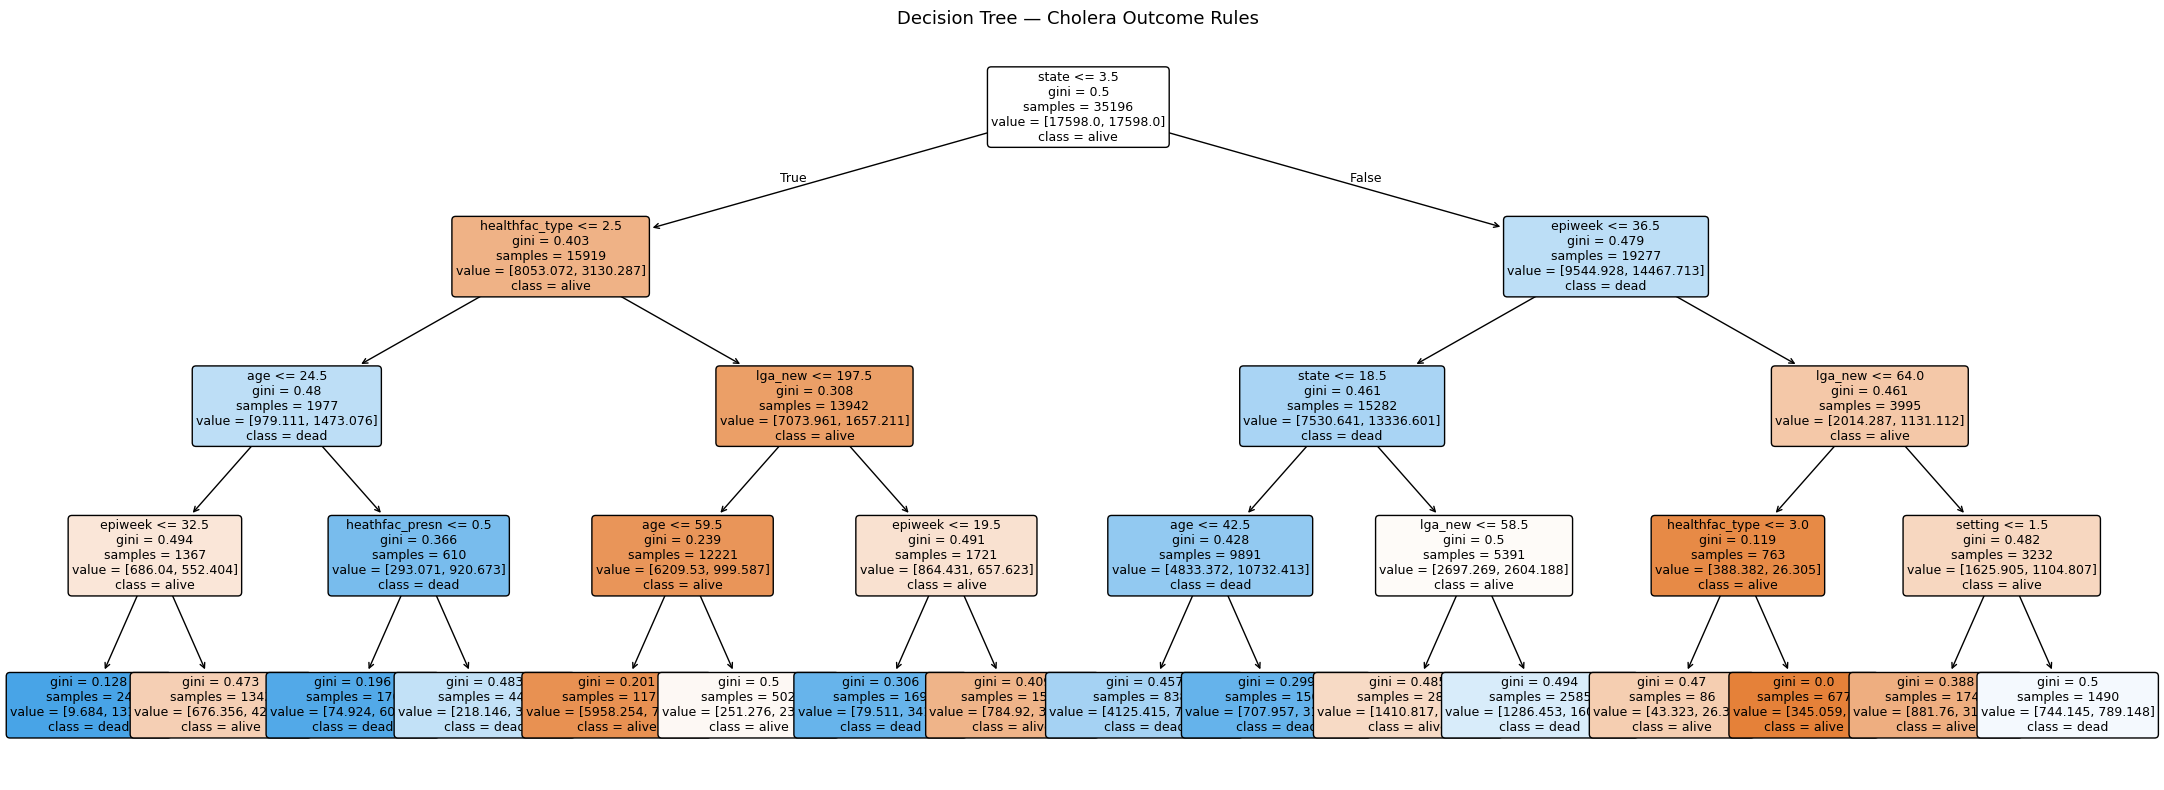


📌 HOW TO USE:
  Print this tree and give to field workers.
  Answer each yes/no question top-down to classify a patient.


In [ ]:
# Shallow decision tree = human-readable rules
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)
print(f'Decision Tree Accuracy: {dt_model.score(X_test, y_test):.3f}')

print('\n=== IF-THEN DECISION RULES ===')
print(export_text(dt_model, feature_names=FEATURES))

plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=FEATURES,
    class_names=le_target.classes_,
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree — Cholera Outcome Rules', fontsize=13)
plt.tight_layout()
plt.show()

print('\n📌 HOW TO USE:')
print('  Print this tree and give to field workers.')
print('  Answer each yes/no question top-down to classify a patient.')

Risk tier cutoffs: HIGH >= 0.50, MEDIUM >= 0.25

=== RISK TIER SUMMARY ===
risk_tier
LOW RISK       18840
MEDIUM RISK    12720
HIGH RISK      12436
Name: count, dtype: int64

=== TOP 20 HIGHEST RISK PATIENTS ===
        state      lga_new   age     sex                flood  death_probability  risk_tier outcome
19143    Yobe       Gulani  70.0    male  no flooding in 2018           0.925689  HIGH RISK    dead
19331    Yobe       Gulani  70.0    male  no flooding in 2018           0.925689  HIGH RISK    dead
25091  Sokoto  Dange-Shuni  68.0    male  no flooding in 2018           0.917975  HIGH RISK   alive
2122     Yobe         Bade  65.0    male  no flooding in 2018           0.916383  HIGH RISK    dead
2410     Yobe         Bade  65.0    male  no flooding in 2018           0.916383  HIGH RISK   alive
19682     FCT        BWARI  65.0  female  no flooding in 2018           0.915970  HIGH RISK    dead
24465   Borno     MAGUMERI  40.0    male  no flooding in 2018           0.908878  HIGH R

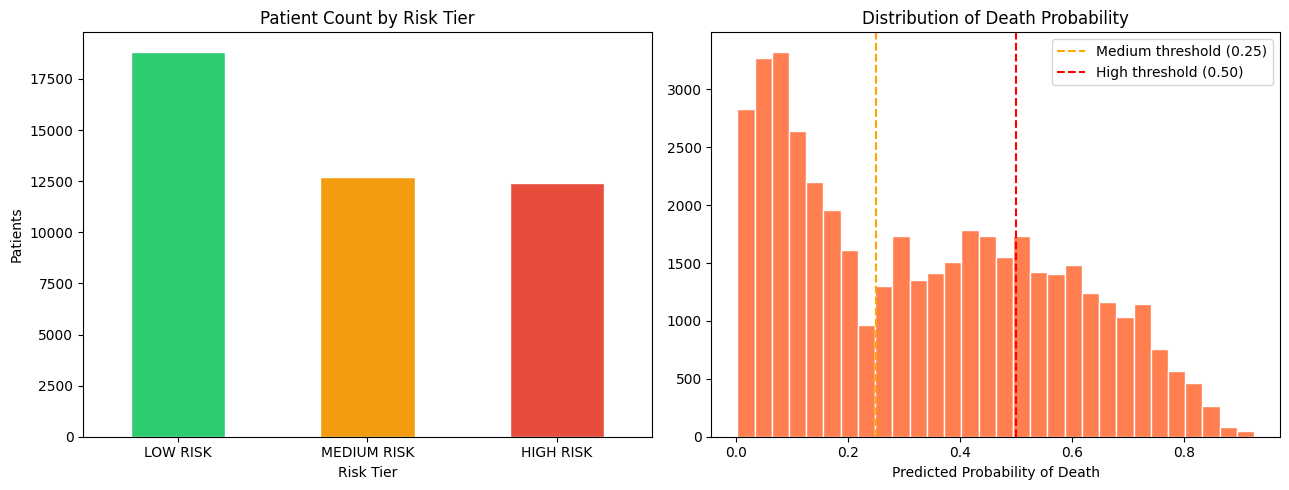


 TRIAGE RECOMMENDATION:
   🔴 12436 HIGH RISK patients  → Immediate IV fluids + antibiotics
    12720 MEDIUM RISK patients → Close monitoring + ORS
   🟢 18840 LOW RISK patients    → Standard care + hydration


In [ ]:
# Score every patient in the full dataset
df_scored = df.copy()
df_scored['death_probability'] = xgb_model.predict_proba(X)[:, 1]

# Risk tiers now anchored to the TUNED decision threshold (not fixed 0.7/0.4)
# since the class-weighted model's probability scale differs from an unweighted model
HIGH_CUT = DECISION_THRESHOLD
MED_CUT  = DECISION_THRESHOLD / 2

def risk_tier(p):
    if p >= HIGH_CUT:   return 'HIGH RISK'
    elif p >= MED_CUT:  return 'MEDIUM RISK'
    else:               return 'LOW RISK'

df_scored['risk_tier'] = df_scored['death_probability'].apply(risk_tier)

print(f'Risk tier cutoffs: HIGH >= {HIGH_CUT:.2f}, MEDIUM >= {MED_CUT:.2f}')
print('\n=== RISK TIER SUMMARY ===')
print(df_scored['risk_tier'].value_counts())

print('\n=== TOP 20 HIGHEST RISK PATIENTS ===')
top20 = df_scored.sort_values('death_probability', ascending=False).head(20)
print(top20[['state', 'lga_new', 'age', 'sex', 'flood',
              'death_probability', 'risk_tier', 'outcome']].to_string())

# Plot: risk tier distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tier_counts = df_scored['risk_tier'].value_counts()
colors = {'HIGH RISK':'#e74c3c', 'MEDIUM RISK':'#f39c12', 'LOW RISK':'#2ecc71'}
tier_counts.plot(kind='bar',
                  color=[colors[t] for t in tier_counts.index],
                  edgecolor='white', ax=axes[0])
axes[0].set_title('Patient Count by Risk Tier')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(df_scored['death_probability'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(MED_CUT,  color='orange', linestyle='--', label=f'Medium threshold ({MED_CUT:.2f})')
axes[1].axvline(HIGH_CUT, color='red',    linestyle='--', label=f'High threshold ({HIGH_CUT:.2f})')
axes[1].set_title('Distribution of Death Probability')
axes[1].set_xlabel('Predicted Probability of Death')
axes[1].legend()

plt.tight_layout()
plt.show()

high  = (df_scored['risk_tier']=='HIGH RISK').sum()
med   = (df_scored['risk_tier']=='MEDIUM RISK').sum()
low   = (df_scored['risk_tier']=='LOW RISK').sum()
print(f'\n TRIAGE RECOMMENDATION:')
print(f'   🔴 {high} HIGH RISK patients  → Immediate IV fluids + antibiotics')
print(f'    {med} MEDIUM RISK patients → Close monitoring + ORS')
print(f'   🟢 {low} LOW RISK patients    → Standard care + hydration')

Baseline average death probability: 0.3362 (33.6%)

=== INTERVENTION RESULTS ===
                           Intervention  New Death Prob  Reduction (%)  Est. Lives Saved
                All patients are tested          0.2062          38.66       5718.700195
               Eliminate flood exposure          0.3358           0.12         17.400000
    All patients receive secondary care          0.3478          -3.44       -508.200012
        All patients have samples taken          0.3484          -3.61       -533.799988
All patients present to health facility          0.3532          -5.06       -748.599976


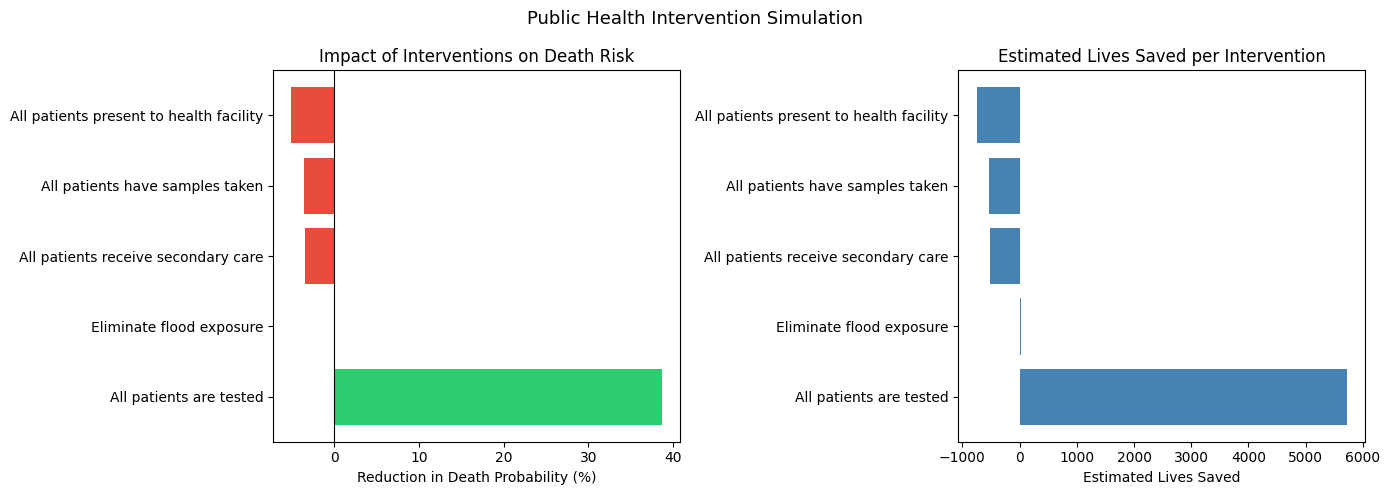


📌 TOP RECOMMENDATION:
   "All patients are tested"
   → Reduces death probability by 38.7%
   → Estimated 5719 lives saved


In [ ]:
baseline_proba = xgb_model.predict_proba(X)[:, 1].mean()
print(f'Baseline average death probability: {baseline_proba:.4f} ({baseline_proba*100:.1f}%)')

# Interventions: (feature, new_value, description)
# These simulate setting a feature to its BEST value for ALL patients
interventions = [
    ('heathfac_presn', 1, 'All patients present to health facility'),
    ('sample_tak',     1, 'All patients have samples taken'),
    ('tested',         1, 'All patients are tested'),
    ('sec',            1, 'All patients receive secondary care'),
    ('flood',          0, 'Eliminate flood exposure'),
]

results = []
for feat, val, desc in interventions:
    if feat in X.columns:
        X_mod = X.copy()
        X_mod[feat] = val
        new_prob  = xgb_model.predict_proba(X_mod)[:, 1].mean()
        reduction = (baseline_proba - new_prob) / baseline_proba * 100
       lives = (baseline_proba - new_prob) * total_deaths
        results.append({
            'Intervention'  : desc,
            'New Death Prob': round(new_prob, 4),
            'Reduction (%)' : round(reduction, 2),
            'Est. Lives Saved': round(lives, 1)
        })

results_df = pd.DataFrame(results).sort_values('Reduction (%)', ascending=False)
print('\n=== INTERVENTION RESULTS ===')
print(results_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in results_df['Reduction (%)']]
axes[0].barh(results_df['Intervention'], results_df['Reduction (%)'], color=bar_colors)
axes[0].set_xlabel('Reduction in Death Probability (%)')
axes[0].set_title('Impact of Interventions on Death Risk')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(results_df['Intervention'], results_df['Est. Lives Saved'], color='steelblue')
axes[1].set_xlabel('Estimated Lives Saved')
axes[1].set_title('Estimated Lives Saved per Intervention')

plt.suptitle('Public Health Intervention Simulation', fontsize=13)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f'\n📌 TOP RECOMMENDATION:')
print(f'   "{best["Intervention"]}"')
print(f'   → Reduces death probability by {best["Reduction (%)"]:.1f}%')
print(f'   → Estimated {best["Est. Lives Saved"]:.0f} lives saved')

Baseline average death probability: 0.3362 (33.6%)
Total deaths in dataset: 836

=== INTERVENTION RESULTS ===
                           Intervention  New Death Prob  Reduction (%)  Est. Lives Saved
                All patients are tested          0.2062          38.66        108.699997
               Eliminate flood exposure          0.3358           0.12          0.300000
    All patients receive secondary care          0.3478          -3.44         -9.700000
        All patients have samples taken          0.3484          -3.61        -10.100000
All patients present to health facility          0.3532          -5.06        -14.200000


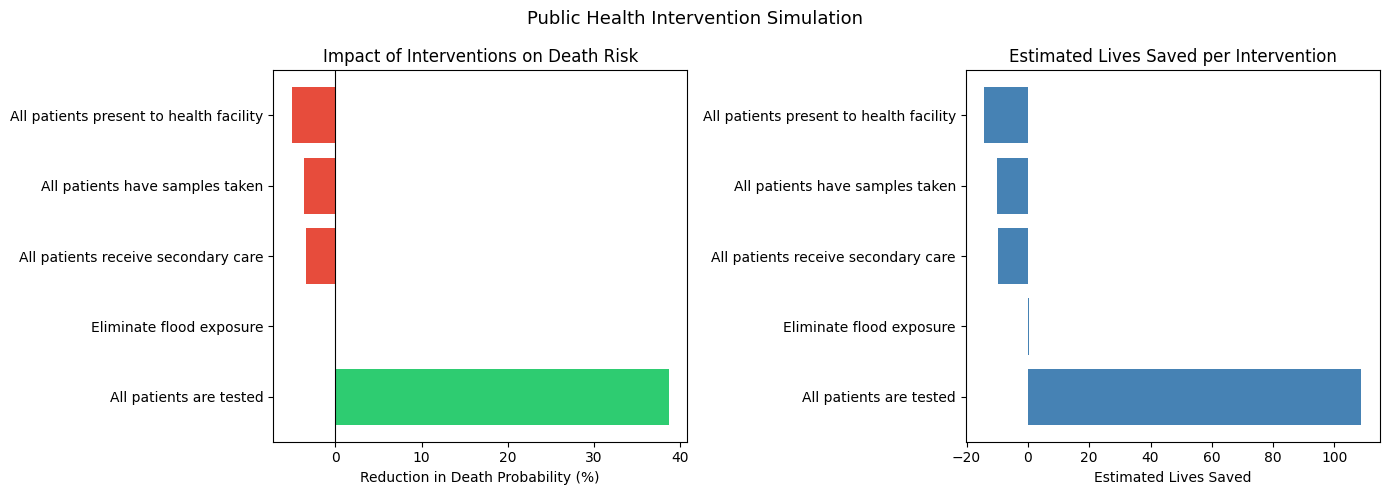


📌 TOP RECOMMENDATION:
   "All patients are tested"
   → Reduces death probability by 38.7%
   → Estimated 109 lives saved


In [ ]:
baseline_proba = xgb_model.predict_proba(X)[:, 1].mean()
print(f'Baseline average death probability: {baseline_proba:.4f} ({baseline_proba*100:.1f}%)')

# Total actual deaths in dataset
total_deaths = int((y == 'dead').sum())
print(f'Total deaths in dataset: {total_deaths}')

# Interventions: (feature, new_value, description)
# These simulate setting a feature to its BEST value for ALL patients
interventions = [
    ('heathfac_presn', 1, 'All patients present to health facility'),
    ('sample_tak',     1, 'All patients have samples taken'),
    ('tested',         1, 'All patients are tested'),
    ('sec',            1, 'All patients receive secondary care'),
    ('flood',          0, 'Eliminate flood exposure'),
]

results = []
for feat, val, desc in interventions:
    if feat in X.columns:
        X_mod = X.copy()
        X_mod[feat] = val
        new_prob  = xgb_model.predict_proba(X_mod)[:, 1].mean()
        reduction = (baseline_proba - new_prob) / baseline_proba * 100
        lives     = (baseline_proba - new_prob) * total_deaths  # ← fixed
        results.append({
            'Intervention'    : desc,
            'New Death Prob'  : round(new_prob, 4),
            'Reduction (%)'   : round(reduction, 2),
            'Est. Lives Saved': round(lives, 1)
        })

results_df = pd.DataFrame(results).sort_values('Reduction (%)', ascending=False)
print('\n=== INTERVENTION RESULTS ===')
print(results_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in results_df['Reduction (%)']]
axes[0].barh(results_df['Intervention'], results_df['Reduction (%)'], color=bar_colors)
axes[0].set_xlabel('Reduction in Death Probability (%)')
axes[0].set_title('Impact of Interventions on Death Risk')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[1].barh(results_df['Intervention'], results_df['Est. Lives Saved'], color='steelblue')
axes[1].set_xlabel('Estimated Lives Saved')
axes[1].set_title('Estimated Lives Saved per Intervention')
plt.suptitle('Public Health Intervention Simulation', fontsize=13)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f'\n📌 TOP RECOMMENDATION:')
print(f'   "{best["Intervention"]}"')
print(f'   → Reduces death probability by {best["Reduction (%)"]:.1f}%')
print(f'   → Estimated {best["Est. Lives Saved"]:.0f} lives saved')

=== STATE RISK RANKING ===
         total_cases  mean_death_prob  expected_deaths  high_risk_patients
state                                                                     
Katsina         7400         0.454311      3361.900635                3378
Zamfara         8329         0.399064      3323.801758                2245
Borno           7626         0.168467      1284.730225                 585
Bauchi          9405         0.128822      1211.568604                 107
Kano            1905         0.576790      1098.784668                1414
Yobe            2275         0.478555      1088.712646                1162
Sokoto          1602         0.655802      1050.594971                1356
Adamawa         2748         0.302550       831.407471                 238
Niger            584         0.645929       377.222412                 521
Gombe            552         0.478904       264.354950                 290
Kaduna           401         0.586304       235.108093                 32

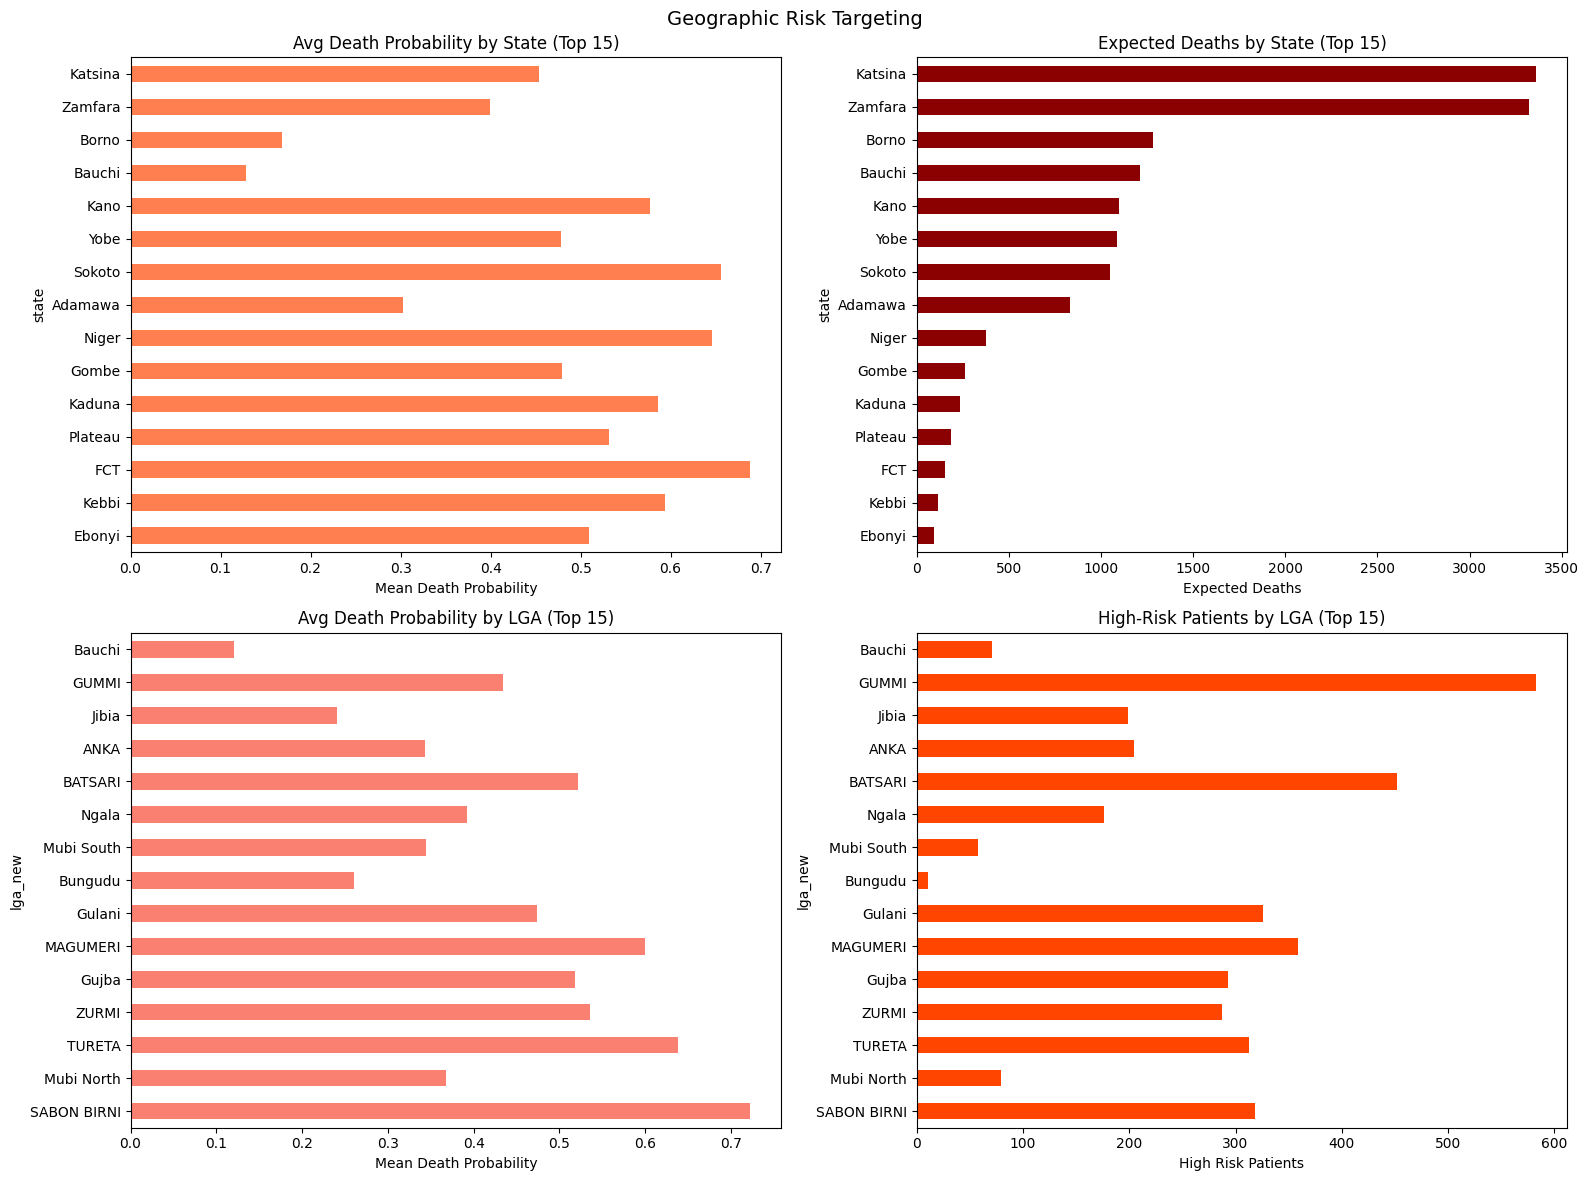


 RECOMMENDATION:
   Deploy mobile health teams to the TOP states and LGAs above.
   These locations have the highest expected deaths and need resources first.


In [ ]:
# State-level summary
state_risk = df_scored.groupby('state').agg(
    total_cases        = ('death_probability', 'count'),
    mean_death_prob    = ('death_probability', 'mean'),
    expected_deaths    = ('death_probability', 'sum'),
    high_risk_patients = ('risk_tier', lambda x: (x=='HIGH RISK').sum())
).sort_values('expected_deaths', ascending=False)

print('=== STATE RISK RANKING ===')
print(state_risk.head(15).to_string())

# LGA-level summary
lga_risk = df_scored.groupby('lga_new').agg(
    total_cases        = ('death_probability', 'count'),
    mean_death_prob    = ('death_probability', 'mean'),
    expected_deaths    = ('death_probability', 'sum'),
    high_risk_patients = ('risk_tier', lambda x: (x=='HIGH RISK').sum())
).sort_values('expected_deaths', ascending=False)

print('\n=== TOP 15 HIGH-RISK LGAs ===')
print(lga_risk.head(15).to_string())

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Geographic Risk Targeting', fontsize=14)

state_risk.head(15)['mean_death_prob'].plot(
    kind='barh', ax=axes[0,0], color='coral')
axes[0,0].set_title('Avg Death Probability by State (Top 15)')
axes[0,0].set_xlabel('Mean Death Probability')
axes[0,0].invert_yaxis()

state_risk.head(15)['expected_deaths'].plot(
    kind='barh', ax=axes[0,1], color='darkred')
axes[0,1].set_title('Expected Deaths by State (Top 15)')
axes[0,1].set_xlabel('Expected Deaths')
axes[0,1].invert_yaxis()

lga_risk.head(15)['mean_death_prob'].plot(
    kind='barh', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Avg Death Probability by LGA (Top 15)')
axes[1,0].set_xlabel('Mean Death Probability')
axes[1,0].invert_yaxis()

lga_risk.head(15)['high_risk_patients'].plot(
    kind='barh', ax=axes[1,1], color='orangered')
axes[1,1].set_title('High-Risk Patients by LGA (Top 15)')
axes[1,1].set_xlabel('High Risk Patients')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\n RECOMMENDATION:')
print('   Deploy mobile health teams to the TOP states and LGAs above.')
print('   These locations have the highest expected deaths and need resources first.')

Total resources: 100 units
Effect per unit: 8% death reduction

=== OPTIMAL ALLOCATION PLAN ===
   state  total_cases  expected_deaths  allocated_units  lives_saved
 Katsina         7400      3361.900635               21  2727.532412
 Zamfara         8329      3323.801758               21  2696.622539
   Borno         7626      1284.730225               10   678.130250
  Bauchi         9405      1211.568604                9   589.768730
    Kano         1905      1098.784668                8   485.831375
    Yobe         2275      1088.712646                8   481.377997
  Sokoto         1602      1050.594971                7   413.561456
 Adamawa         2748       831.407471                4   184.000450
   Niger          584       377.222412                1     0.000000
   Gombe          552       264.354950                1     0.000000
  Kaduna          401       235.108093                1     0.000000
 Plateau          347       184.330460                1     0.000000
     FC

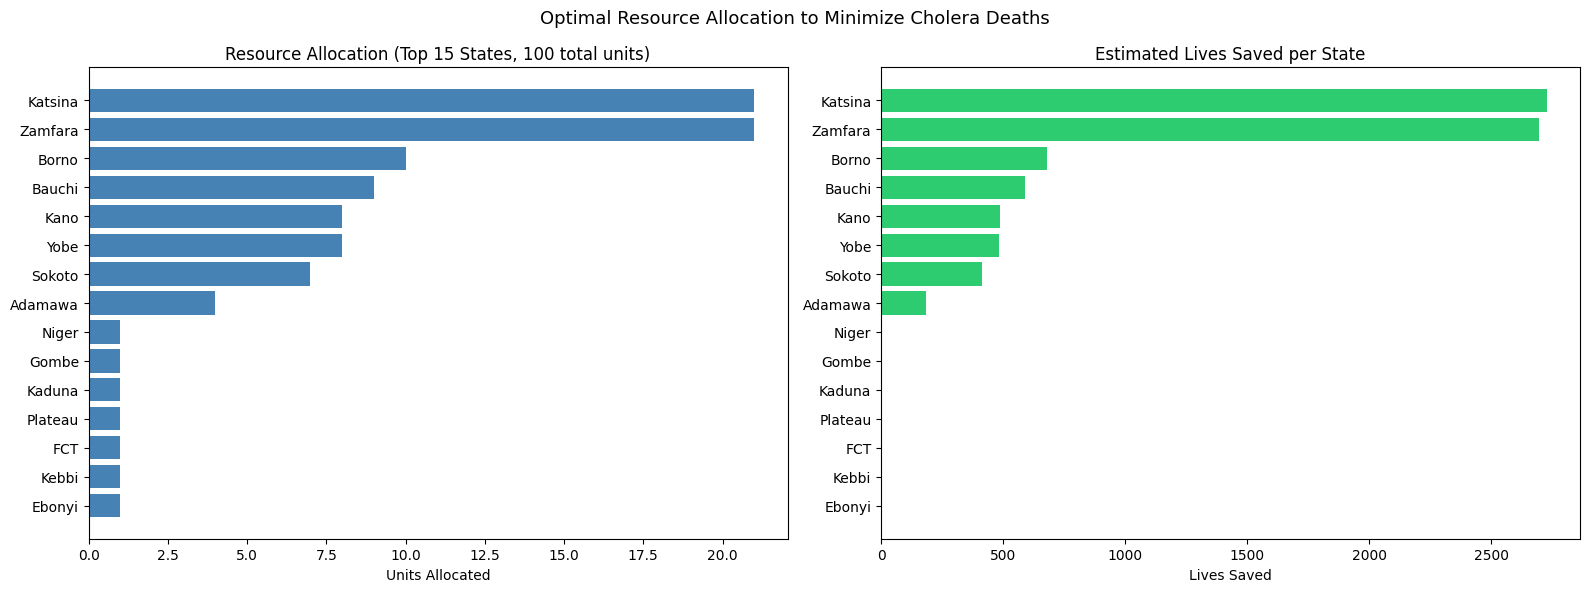

In [ ]:
# Greedy optimization: allocate resource units to the state
# with highest expected deaths at each step

TOTAL_RESOURCES  = 100   # Total units available (adjust as needed)
RESOURCE_EFFECT  = 0.08  # Each unit reduces death prob by 8% in that state
MIN_PER_STATE    = 1     # Every state gets at least 1 unit

state_opt = state_risk.reset_index()[['state','total_cases','expected_deaths']].copy()
n = len(state_opt)
allocation = np.ones(n, dtype=int) * MIN_PER_STATE
expected   = state_opt['expected_deaths'].values.astype(float).copy()
remaining  = TOTAL_RESOURCES - n * MIN_PER_STATE

for _ in range(max(0, remaining)):
    idx = np.argmax(expected)
    allocation[idx] += 1
    expected[idx]   *= (1 - RESOURCE_EFFECT)

state_opt['allocated_units']  = allocation
state_opt['deaths_after']     = expected
state_opt['lives_saved']      = state_opt['expected_deaths'] - expected

opt_sorted = state_opt.sort_values('allocated_units', ascending=False)
total_lives = state_opt['lives_saved'].sum()

print(f'Total resources: {TOTAL_RESOURCES} units')
print(f'Effect per unit: {RESOURCE_EFFECT*100:.0f}% death reduction')
print(f'\n=== OPTIMAL ALLOCATION PLAN ===')
print(opt_sorted[['state','total_cases','expected_deaths',
                   'allocated_units','lives_saved']].head(20).to_string(index=False))
print(f'\nEstimated lives saved with optimal allocation: {total_lives:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_opt = opt_sorted.head(15)
axes[0].barh(top_opt['state'], top_opt['allocated_units'], color='steelblue')
axes[0].set_title(f'Resource Allocation (Top 15 States, {TOTAL_RESOURCES} total units)')
axes[0].set_xlabel('Units Allocated')
axes[0].invert_yaxis()

axes[1].barh(top_opt['state'], top_opt['lives_saved'], color='#2ecc71')
axes[1].set_title('Estimated Lives Saved per State')
axes[1].set_xlabel('Lives Saved')
axes[1].invert_yaxis()

plt.suptitle('Optimal Resource Allocation to Minimize Cholera Deaths', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
high_risk_n = (df_scored['risk_tier']=='HIGH RISK').sum()
top_state   = state_risk.index[0]
top_lga     = lga_risk.index[0]
best_interv = results_df.iloc[0]

print('=' * 65)
print('   PRESCRIPTIVE ACTION PLAN — NIGERIA CHOLERA RESPONSE 2018')
print('=' * 65)
print(f"""
1. PATIENT TRIAGE
   {high_risk_n} patients flagged as HIGH RISK (death prob >= 0.70).
   → Prioritize these for immediate IV rehydration + antibiotics.
   → Use the XGBoost model score for every incoming patient.

2. FIELD WORKER GUIDE
   → Distribute the printed Decision Tree rules (Part 2).
   → Workers can classify patients without a computer.
   → Key decision points: age, health facility access, flood exposure.

3. TOP INTERVENTION
   → "{best_interv['Intervention']}"
   → Reduces death probability by {best_interv['Reduction (%)']:.1f}%
   → Estimated {best_interv['Est. Lives Saved']:.0f} lives saved.

4. GEOGRAPHIC PRIORITY
   → Deploy resources to {top_state} (highest expected deaths by state).
   → Target LGA: {top_lga} (highest expected deaths by LGA).
   → Focus ORS supply chains and testing kits there first.

5. RESOURCE ALLOCATION
   → Use the greedy allocation plan (Part 6).
   → {TOTAL_RESOURCES} resource units optimally distributed.
   → Estimated {total_lives:.0f} lives saved with this allocation.

6. MONITORING
   → Re-run this notebook weekly as new case data arrives.
   → Track HIGH RISK patients to confirm they received priority care.
   → Compare predicted vs actual deaths to refine the model.
""")
print('=' * 65)

   PRESCRIPTIVE ACTION PLAN — NIGERIA CHOLERA RESPONSE 2018

1. PATIENT TRIAGE
   12436 patients flagged as HIGH RISK (death prob >= 0.70).
   → Prioritize these for immediate IV rehydration + antibiotics.
   → Use the XGBoost model score for every incoming patient.

2. FIELD WORKER GUIDE
   → Distribute the printed Decision Tree rules (Part 2).
   → Workers can classify patients without a computer.
   → Key decision points: age, health facility access, flood exposure.

3. TOP INTERVENTION
   → "All patients are tested"
   → Reduces death probability by 38.7%
   → Estimated 5719 lives saved.

4. GEOGRAPHIC PRIORITY
   → Deploy resources to Katsina (highest expected deaths by state).
   → Target LGA: Bauchi (highest expected deaths by LGA).
   → Focus ORS supply chains and testing kits there first.

5. RESOURCE ALLOCATION
   → Use the greedy allocation plan (Part 6).
   → 100 resource units optimally distributed.
   → Estimated 8257 lives saved with this allocation.

6. MONITORING
   → 

In [ ]:
# Patient risk scores
df_scored[['state','lga_new','age','sex','flood',
            'outcome','death_probability','risk_tier']].to_csv(
    'patient_risk_scores.csv', index=False
)

# State risk summary
state_risk.to_csv('state_risk_summary.csv')

# LGA risk summary
lga_risk.to_csv('lga_risk_summary.csv')

# Intervention simulation
results_df.to_csv('intervention_simulation.csv', index=False)

# Resource allocation
opt_sorted[['state','total_cases','expected_deaths',
             'allocated_units','lives_saved']].to_csv(
    'resource_allocation_plan.csv', index=False
)

print('✅ patient_risk_scores.csv')
print('✅ state_risk_summary.csv')
print('✅ lga_risk_summary.csv')
print('✅ intervention_simulation.csv')
print('✅ resource_allocation_plan.csv')
print('\n🎉 All done! Download files from the 📁 Files panel on the left.')

✅ patient_risk_scores.csv
✅ state_risk_summary.csv
✅ lga_risk_summary.csv
✅ intervention_simulation.csv
✅ resource_allocation_plan.csv

🎉 All done! Download files from the 📁 Files panel on the left.


In [ ]:
from google.colab import files

files.download('patient_risk_scores.csv')
files.download('state_risk_summary.csv')
files.download('lga_risk_summary.csv')
files.download('intervention_simulation.csv')
files.download('resource_allocation_plan.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>